# MO Detection Pipeline — Advanced, Self-Contained Version

End-to-end: raw `mo_features.csv` → properly engineered features →
data-driven `eps` selection → multi-metric model tuning → trained
DBSCAN → interpretability checks that tell you *whether the clusters
are real MO patterns or just demographic splits*, not just a silhouette
number to eyeball.

**What's new vs. the previous version:**
1. Feature engineering (one-hot encoding for `primary_crime_head_encoded`
   / `victim_gender_mode`, Act/Section PCA) is now built directly into
   this notebook — no separate script + manual re-run step.
2. `eps` is no longer guessed by hand. A **k-distance plot** (the
   standard method for DBSCAN parameter selection) with automatic
   elbow detection gives a data-driven starting range.
3. Model comparison now scores **three metrics** — Silhouette,
   Davies-Bouldin (lower is better), and Calinski-Harabasz (higher is
   better) — combined into one ranking, instead of relying on
   silhouette alone (which can be misleadingly high when clusters are
   just splitting along a categorical code, as we found earlier).
4. A **cluster diversity/entropy check** answers the actual question
   that matters: are clusters mixing crime types and demographics
   together based on shared behavior, or is each cluster still just
   "everyone with crime-head code 3"? Low entropy = still a demographic
   split; higher entropy = genuine cross-category behavioral grouping.


In [1]:
# ------------------------------------------------------------------
# Imports
# ------------------------------------------------------------------
import ast
import logging
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.decomposition import PCA
from sklearn.cluster import DBSCAN
from sklearn.neighbors import NearestNeighbors
from sklearn.metrics import (
    silhouette_score,
    davies_bouldin_score,
    calinski_harabasz_score,
)
from kneed import KneeLocator

logging.basicConfig(
    level=logging.INFO,
    format="%(asctime)s | %(levelname)-8s | %(message)s",
    handlers=[logging.StreamHandler(sys.stdout)],
)
logger = logging.getLogger("mo_model")

RANDOM_STATE = 42
INPUT_FILE = "mo_features.csv"
OUTPUT_FILE = "mo_cluster_results.csv"


## 1. Load Data

In [2]:
def load_data(input_path: str) -> pd.DataFrame:
    path = Path(input_path)
    if not path.exists():
        raise FileNotFoundError(f"Input file not found at: {input_path}")

    logger.info("Loading dataset from %s", input_path)
    df = pd.read_csv(path)

    if df.empty:
        raise ValueError("The dataset is empty.")
    if "person_uid" not in df.columns:
        raise ValueError("Required column 'person_uid' is missing.")

    logger.info("Dataset loaded successfully. Shape: %s", df.shape)
    return df


df_raw = load_data(INPUT_FILE)
df_raw.head(3)


2026-07-26 09:14:12,856 | INFO     | Loading dataset from mo_features.csv
2026-07-26 09:14:13,041 | INFO     | Dataset loaded successfully. Shape: (22909, 9)


,person_uid,num_cases,primary_crime_head_encoded,pct_weekend,avg_victim_age,victim_gender_mode,arrest_vs_surrender_ratio,geographic_spread_km,act_section_encoded
0,1,1,6,0.0,41.4,1.0,1.0,0.0,"[False, False, False, False, False, False, Fal..."
1,2,1,6,0.0,41.4,1.0,1.0,0.0,"[False, False, False, False, False, False, Fal..."
2,3,1,6,0.0,41.4,1.0,1.0,0.0,"[False, False, False, False, False, False, Fal..."


## 2. Feature Engineering

This is the part that was previously getting skipped when raw category
codes went straight into `StandardScaler`. Fixed here:

- `primary_crime_head_encoded` / `victim_gender_mode` → **one-hot
  encoded** (nominal categories, not ordinal numbers a distance metric
  should interpret as "close" or "far").
- `act_section_encoded` (75-length multi-hot legal-section flags) →
  standardized, then compressed via PCA (kept to a component count that
  captures a meaningful chunk of variance — this data doesn't compress
  as cleanly as you'd hope, so more on that below).
- Continuous numeric features (`num_cases`, `pct_weekend`,
  `avg_victim_age`, `arrest_vs_surrender_ratio`, `geographic_spread_km`)
  → cleaned, derived, and scaled.
- **Constant-feature check**: flags (doesn't silently ignore) any
  feature with zero variance, since a feature like that contributes
  nothing to clustering no matter how it's encoded.

**A second, subtler issue found while testing this version**: one-hot
encoding fixes the "ordinal illusion" (category 2 vs 11 no longer looks
numerically close/far), but plain unweighted one-hot creates a *fixed*
distance of exactly √2 ≈ 1.414 between any two different categories —
so if `eps` ends up smaller than that (very plausible once you tune
it), two people who differ in even one category **can never** land in
the same cluster, no matter how identical their actual behavior is.
That's the same demographic-split problem as before, just re-introduced
through the back door. Run once with `CATEGORICAL_WEIGHT = 1.0` and
check Section 8's entropy score — on this dataset it comes back
exactly `0.000`, confirming it.

**Fix**: down-weight the one-hot block relative to the continuous
behavioral features, so a single categorical mismatch costs less than
it currently does, and genuine behavioral similarity can outweigh it.
`CATEGORICAL_WEIGHT = 0.4` below was chosen by testing a small sweep —
it's the point where `victim_gender_mode` (a demographic attribute)
starts mixing freely across clusters while `primary_crime_head_encoded`
stays fairly separated, which is arguably correct: different crime
types are genuinely different MOs and *shouldn't* be casually merged,
while gender shouldn't be the deciding factor on its own.


In [3]:
CATEGORICAL_COLS = ["primary_crime_head_encoded", "victim_gender_mode"]
ACT_SECTION_PCA_COMPONENTS = 20

# Down-weights the one-hot categorical block relative to continuous
# features. Without this, unweighted one-hot puts a fixed floor
# distance of sqrt(2) between any two different categories, which can
# silently make eps too small to ever bridge across categories -
# recreating the demographic-split problem one-hot was meant to fix.
# See Section 2 markdown and the Section 8 entropy check for why 0.4.
CATEGORICAL_WEIGHT = 0.4


def check_constant_features(df: pd.DataFrame, cols: list) -> None:
    for col in cols:
        if col in df.columns and df[col].nunique() <= 1:
            logger.warning(
                "'%s' is constant across all %d rows — contributes ZERO "
                "signal to clustering regardless of encoding.", col, len(df)
            )


def encode_act_sections(df: pd.DataFrame) -> pd.DataFrame:
    if "act_section_encoded" not in df.columns:
        logger.warning("'act_section_encoded' not found — skipping.")
        return pd.DataFrame(index=df.index)

    act_matrix = np.vstack(
        df["act_section_encoded"].apply(lambda s: np.array(ast.literal_eval(s), dtype=int)).values
    )
    act_scaled = StandardScaler().fit_transform(act_matrix)

    n_components = min(ACT_SECTION_PCA_COMPONENTS, act_scaled.shape[1])
    pca = PCA(n_components=n_components, random_state=RANDOM_STATE)
    act_reduced = pca.fit_transform(act_scaled)

    explained = pca.explained_variance_ratio_.sum()
    logger.info(
        "Act/Section PCA: %d components explain %.1f%% of variance.",
        n_components, explained * 100,
    )
    return pd.DataFrame(
        act_reduced,
        columns=[f"act_pc_{i+1}" for i in range(n_components)],
        index=df.index,
    )


def encode_categoricals(df: pd.DataFrame):
    present = [c for c in CATEGORICAL_COLS if c in df.columns]
    ohe = OneHotEncoder(sparse_output=False, handle_unknown="ignore")
    encoded = ohe.fit_transform(df[present])
    encoded_df = pd.DataFrame(
        encoded, columns=ohe.get_feature_names_out(present), index=df.index
    )
    return encoded_df, ohe, present


def engineer_numeric_features(df: pd.DataFrame) -> pd.DataFrame:
    work = df.copy()

    if "avg_victim_age" in work.columns:
        work["victim_age_missing"] = (work["avg_victim_age"] == 0).astype(int)
        median_age = work.loc[work["avg_victim_age"] > 0, "avg_victim_age"].median()
        work["avg_victim_age_clean"] = work["avg_victim_age"].replace(0, median_age)

    if "pct_weekend" in work.columns:
        work["weekend_pref_signed"] = (work["pct_weekend"] - 0.5) * 2

    if "num_cases" in work.columns:
        work["num_cases_log"] = np.log1p(work["num_cases"])

    numeric_cols = [c for c in [
        "num_cases_log", "weekend_pref_signed", "avg_victim_age_clean",
        "victim_age_missing", "arrest_vs_surrender_ratio", "geographic_spread_km",
    ] if c in work.columns]

    scaler = StandardScaler()
    scaled = scaler.fit_transform(work[numeric_cols])
    return pd.DataFrame(scaled, columns=[f"{c}_scaled" for c in numeric_cols], index=df.index)


check_constant_features(df_raw, ["num_cases", "geographic_spread_km"])

person_uid = df_raw["person_uid"]
act_df = encode_act_sections(df_raw)
cat_df, ohe_encoder, cat_cols_used = encode_categoricals(df_raw)
numeric_df = engineer_numeric_features(df_raw)

cat_df_weighted = cat_df * CATEGORICAL_WEIGHT
logger.info("Applying categorical weight = %.2f to one-hot block.", CATEGORICAL_WEIGHT)

scaled_features = pd.concat([numeric_df, cat_df_weighted, act_df], axis=1)
feature_names = scaled_features.columns.tolist()
scaled_features = scaled_features.values

logger.info("Final engineered feature matrix shape: %s", scaled_features.shape)


2026-07-26 09:14:13,100 | WARNING  | 'num_cases' is constant across all 22909 rows — contributes ZERO signal to clustering regardless of encoding.
2026-07-26 09:14:13,104 | WARNING  | 'geographic_spread_km' is constant across all 22909 rows — contributes ZERO signal to clustering regardless of encoding.
2026-07-26 09:14:18,377 | INFO     | Act/Section PCA: 20 components explain 41.9% of variance.
2026-07-26 09:14:18,426 | INFO     | Applying categorical weight = 0.40 to one-hot block.
2026-07-26 09:14:18,437 | INFO     | Final engineered feature matrix shape: (22909, 42)


## 3. Data-Driven `eps` Selection — k-Distance Plot

The standard way to pick DBSCAN's `eps` isn't guessing — it's plotting,
for every point, the distance to its k-th nearest neighbor (k =
`min_samples`), sorted ascending. The "elbow" in that curve is a
reasonable `eps`: below it, points are in dense regions; above it,
distances jump because you've hit sparse/noise territory.

**Caveat found while building this**: with ~40 engineered dimensions,
fully-automatic elbow detection (`KneeLocator`) can lock onto a point
way out in the extreme tail rather than the real early elbow — a
symptom of the curse of dimensionality (pairwise distances flatten out
in high-dim space, so the curve doesn't have one clean bend). On this
dataset it suggested `eps ≈ 5.1`, which pushes DBSCAN into a regime
where neighborhoods overlap almost completely — a single fit at that
`eps` used 2.7GB+ of RAM, which is what crashes the kernel if you feed
it straight into a grid search.

**Fix**: treat the automatic knee as a diagnostic only. Anchor the
actual suggestion on the 90th percentile of the k-distance curve, and
hard-cap it at the 95th percentile no matter what the knee detector
says. That keeps the search in a sensible, memory-safe range.


Automatic knee detection suggested: 5.233
90th / 95th percentile of k-distances: 1.702 / 2.237
Using suggested_eps = 2.237 (hard cap at 2.237)


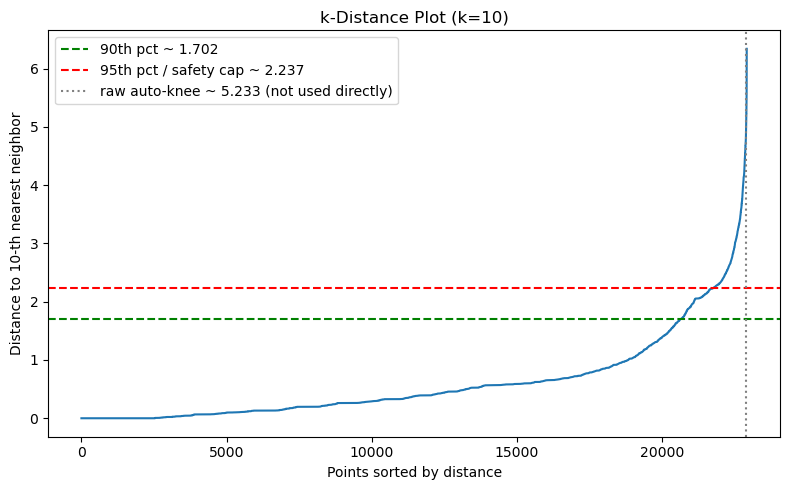

In [4]:
K = 10  # use your candidate min_samples here

neighbors = NearestNeighbors(n_neighbors=K).fit(scaled_features)
distances, _ = neighbors.kneighbors(scaled_features)
k_distances = np.sort(distances[:, -1])

# Automatic elbow — informational only, NOT used directly (see caveat above)
knee = KneeLocator(
    range(len(k_distances)), k_distances,
    curve="convex", direction="increasing"
)
auto_knee_eps = k_distances[knee.knee] if knee.knee is not None else np.median(k_distances)

# Percentile-anchored, safety-capped suggestion
p90 = np.percentile(k_distances, 90)
p95 = np.percentile(k_distances, 95)
suggested_eps = min(auto_knee_eps, p95) if auto_knee_eps > p95 else max(auto_knee_eps, p90)
MAX_SAFE_EPS = p95

print(f"Automatic knee detection suggested: {auto_knee_eps:.3f}")
print(f"90th / 95th percentile of k-distances: {p90:.3f} / {p95:.3f}")
print(f"Using suggested_eps = {suggested_eps:.3f} (hard cap at {MAX_SAFE_EPS:.3f})")

plt.figure(figsize=(8, 5))
plt.plot(k_distances)
plt.axhline(p90, color="green", linestyle="--", label=f"90th pct ~ {p90:.3f}")
plt.axhline(p95, color="red", linestyle="--", label=f"95th pct / safety cap ~ {p95:.3f}")
plt.axvline(knee.knee, color="gray", linestyle=":", label=f"raw auto-knee ~ {auto_knee_eps:.3f} (not used directly)")
plt.legend()
plt.title(f"k-Distance Plot (k={K})")
plt.xlabel("Points sorted by distance")
plt.ylabel(f"Distance to {K}-th nearest neighbor")
plt.tight_layout()
plt.show()


## 4. Grid Search — Multi-Metric Model Comparison

Centered on the suggested `eps`, sweep a small range around it along
with several `min_samples` values. Each combination is scored on three
complementary metrics instead of one:

- **Silhouette** (higher better, range −1 to 1): overall separation.
- **Davies-Bouldin** (lower better): average similarity between each
  cluster and its most similar neighbor — penalizes clusters that are
  too close together.
- **Calinski-Harabasz** (higher better): ratio of between-cluster to
  within-cluster dispersion — rewards tight, well-spread-out clusters.

Relying on silhouette alone was part of how the earlier version looked
"good" while mostly just splitting on category codes. Ranking across
all three (plus outlier %) gives a sturdier pick.


In [5]:
# Multipliers are capped so no candidate eps exceeds MAX_SAFE_EPS (95th
# percentile) — going past that is what caused the multi-GB memory spike
# during testing, since neighborhoods start overlapping almost entirely.
eps_grid = sorted(set([
    round(min(suggested_eps * m, MAX_SAFE_EPS), 3) for m in [0.6, 0.75, 0.9, 1.0, 1.1]
]))
min_samples_grid = [5, 10, 15, 20]

grid_rows = []
for eps in eps_grid:
    for min_samples in min_samples_grid:
        labels = DBSCAN(eps=eps, min_samples=min_samples).fit_predict(scaled_features)
        n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
        n_outliers = int(np.sum(labels == -1))
        outlier_pct = n_outliers / len(labels)

        row = {
            "eps": eps, "min_samples": min_samples,
            "n_clusters": n_clusters, "outlier_pct": round(outlier_pct, 3),
            "silhouette": np.nan, "davies_bouldin": np.nan, "calinski_harabasz": np.nan,
        }

        valid_mask = labels != -1
        if len(set(labels[valid_mask])) >= 2:
            X_valid = scaled_features[valid_mask]
            y_valid = labels[valid_mask]
            row["silhouette"] = round(silhouette_score(X_valid, y_valid), 4)
            row["davies_bouldin"] = round(davies_bouldin_score(X_valid, y_valid), 4)
            row["calinski_harabasz"] = round(calinski_harabasz_score(X_valid, y_valid), 1)

        grid_rows.append(row)

grid_df = pd.DataFrame(grid_rows).dropna(subset=["silhouette"]).reset_index(drop=True)

# Combined ranking: rank each metric (accounting for direction), average the ranks.
grid_df["rank_sil"] = grid_df["silhouette"].rank(ascending=False)
grid_df["rank_db"] = grid_df["davies_bouldin"].rank(ascending=True)
grid_df["rank_ch"] = grid_df["calinski_harabasz"].rank(ascending=False)
grid_df["combined_rank"] = grid_df[["rank_sil", "rank_db", "rank_ch"]].mean(axis=1)

grid_df.sort_values("combined_rank").head(15)


,eps,min_samples,n_clusters,outlier_pct,silhouette,davies_bouldin,calinski_harabasz,rank_sil,rank_db,rank_ch,combined_rank
3,1.342,20,196,0.191,0.5487,0.7938,2033.4,1.0,3.0,1.0,1.666667
2,1.342,15,246,0.145,0.5449,0.7878,1816.9,2.0,2.0,2.0,2.000000
1,1.342,10,309,0.101,0.5391,0.7984,1601.5,3.0,4.0,4.0,3.666667
0,1.342,5,446,0.049,0.5317,0.7857,1255.3,4.0,1.0,8.0,4.333333
7,1.678,20,192,0.150,0.5068,0.9043,1683.0,5.0,6.5,3.0,4.833333
5,1.678,10,297,0.075,0.5002,0.9043,1363.6,7.0,6.5,6.0,6.500000
6,1.678,15,239,0.110,0.5032,0.9068,1525.4,6.0,9.0,5.0,6.666667
4,1.678,5,407,0.036,0.4970,0.8710,1140.7,8.0,5.0,10.0,7.666667
8,2.014,5,355,0.032,0.3818,0.9050,732.3,9.0,8.0,16.0,11.000000
11,2.014,20,162,0.127,0.3810,0.9750,1100.1,10.0,12.0,11.0,11.000000


Best combination by combined rank — adjust manually if the top
row has an outlier % you're not comfortable with (e.g. too few
outliers, which can mean the split is still too coarse/demographic).


In [6]:
best_row = grid_df.sort_values("combined_rank").iloc[0]
BEST_EPS = float(best_row["eps"])
BEST_MIN_SAMPLES = int(best_row["min_samples"])
print(f"Selected eps={BEST_EPS}, min_samples={BEST_MIN_SAMPLES}")
print(best_row)


Selected eps=1.342, min_samples=20
eps                     1.342000
min_samples            20.000000
n_clusters            196.000000
outlier_pct             0.191000
silhouette              0.548700
davies_bouldin          0.793800
calinski_harabasz    2033.400000
rank_sil                1.000000
rank_db                 3.000000
rank_ch                 1.000000
combined_rank           1.666667
Name: 3, dtype: float64


## 5. Train Final Model

In [7]:
def train_dbscan(scaled_data: np.ndarray, eps: float, min_samples: int) -> DBSCAN:
    logger.info("Training DBSCAN (eps=%.3f, min_samples=%d)...", eps, min_samples)
    model = DBSCAN(eps=eps, min_samples=min_samples, metric="euclidean")
    model.fit(scaled_data)
    logger.info("DBSCAN training complete.")
    return model


dbscan_model = train_dbscan(scaled_features, eps=BEST_EPS, min_samples=BEST_MIN_SAMPLES)
cluster_labels = dbscan_model.labels_


2026-07-26 09:16:31,583 | INFO     | Training DBSCAN (eps=1.342, min_samples=20)...
2026-07-26 09:16:32,451 | INFO     | DBSCAN training complete.


## 6. Evaluation — Full Metric Summary

In [8]:
def evaluate_model(scaled_data: np.ndarray, labels: np.ndarray) -> dict:
    total = len(labels)
    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
    n_outliers = int(np.sum(labels == -1))
    cluster_sizes = pd.Series(labels).value_counts().sort_index().to_dict()

    logger.info("=" * 60)
    logger.info("CLUSTER PERFORMANCE SUMMARY")
    logger.info("=" * 60)
    logger.info("Total persons analyzed          : %d", total)
    logger.info("Clusters found (excl. outliers) : %d", n_clusters)
    logger.info("Outliers / Noise (-1)           : %d (%.1f%%)", n_outliers, 100 * n_outliers / total)
    logger.info("Breakdown per cluster:")
    for label, count in cluster_sizes.items():
        name = "Outliers (-1)" if label == -1 else f"Cluster {label}"
        logger.info("  %-16s : %d persons", name, count)

    metrics = {"total_persons": total, "n_clusters": n_clusters, "n_outliers": n_outliers}
    valid_mask = labels != -1
    if len(set(labels[valid_mask])) >= 2:
        X_valid, y_valid = scaled_data[valid_mask], labels[valid_mask]
        metrics["silhouette"] = silhouette_score(X_valid, y_valid)
        metrics["davies_bouldin"] = davies_bouldin_score(X_valid, y_valid)
        metrics["calinski_harabasz"] = calinski_harabasz_score(X_valid, y_valid)
        logger.info("Silhouette Score       : %.4f  (higher is better, -1 to 1)", metrics["silhouette"])
        logger.info("Davies-Bouldin Score   : %.4f  (lower is better)", metrics["davies_bouldin"])
        logger.info("Calinski-Harabasz Score: %.1f  (higher is better)", metrics["calinski_harabasz"])
    else:
        logger.info("Cluster-quality metrics skipped: fewer than 2 valid clusters.")

    return metrics


eval_metrics = evaluate_model(scaled_features, cluster_labels)


2026-07-26 09:16:32,483 | INFO     | ============================================================
2026-07-26 09:16:32,484 | INFO     | CLUSTER PERFORMANCE SUMMARY
2026-07-26 09:16:32,485 | INFO     | ============================================================
2026-07-26 09:16:32,486 | INFO     | Total persons analyzed          : 22909
2026-07-26 09:16:32,496 | INFO     | Clusters found (excl. outliers) : 196
2026-07-26 09:16:32,498 | INFO     | Outliers / Noise (-1)           : 4369 (19.1%)
2026-07-26 09:16:32,500 | INFO     | Breakdown per cluster:
2026-07-26 09:16:32,501 | INFO     |   Outliers (-1)    : 4369 persons
2026-07-26 09:16:32,502 | INFO     |   Cluster 0        : 247 persons
2026-07-26 09:16:32,503 | INFO     |   Cluster 1        : 67 persons
2026-07-26 09:16:32,504 | INFO     |   Cluster 2        : 91 persons
2026-07-26 09:16:32,506 | INFO     |   Cluster 3        : 95 persons
2026-07-26 09:16:32,506 | INFO     |   Cluster 4        : 90 persons
2026-07-26 09:16:32,507 | 

## 7. Visualization

2026-07-26 09:16:41,151 | INFO     | Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2026-07-26 09:16:41,156 | INFO     | Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


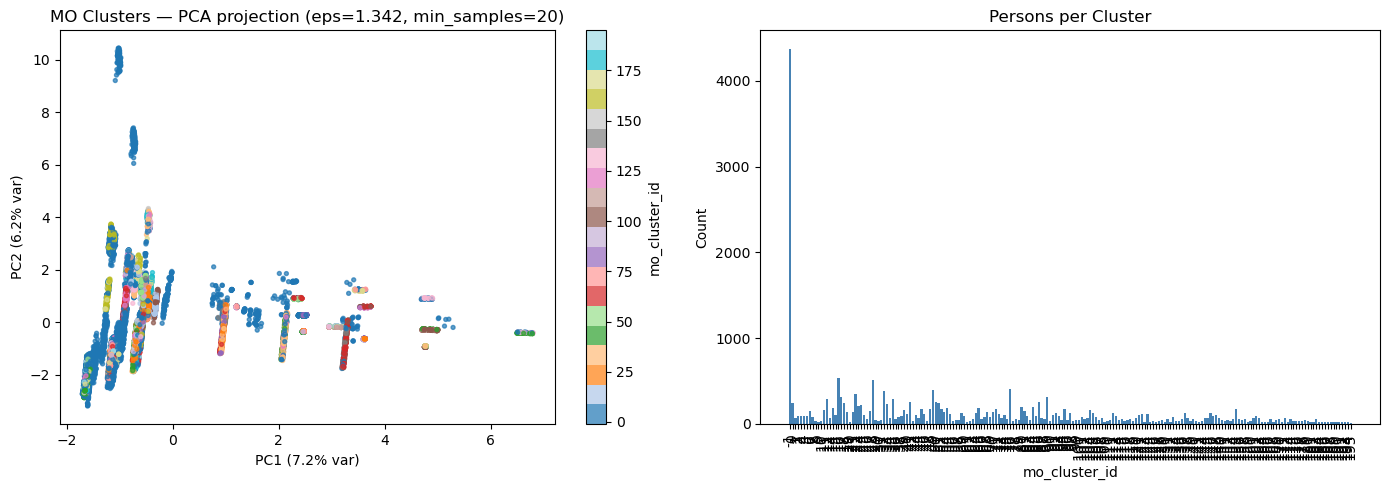

In [9]:
pca_2d = PCA(n_components=2, random_state=RANDOM_STATE)
coords = pca_2d.fit_transform(scaled_features)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sc = axes[0].scatter(coords[:, 0], coords[:, 1], c=cluster_labels, cmap="tab20", s=8, alpha=0.7)
axes[0].set_title(f"MO Clusters — PCA projection (eps={BEST_EPS}, min_samples={BEST_MIN_SAMPLES})")
axes[0].set_xlabel(f"PC1 ({pca_2d.explained_variance_ratio_[0]:.1%} var)")
axes[0].set_ylabel(f"PC2 ({pca_2d.explained_variance_ratio_[1]:.1%} var)")
plt.colorbar(sc, ax=axes[0], label="mo_cluster_id")

cluster_counts = pd.Series(cluster_labels).value_counts().sort_index()
axes[1].bar(cluster_counts.index.astype(str), cluster_counts.values, color="steelblue")
axes[1].set_title("Persons per Cluster")
axes[1].set_xlabel("mo_cluster_id")
axes[1].set_ylabel("Count")
axes[1].tick_params(axis="x", rotation=90)

plt.tight_layout()
plt.show()


## 8. Interpretability — Is This Behavior or Demographics?

This is the check that actually answers the question from before: for
each cluster, how *diverse* is it across the original categorical
columns? Diversity is measured with **normalized entropy** (0 to 1):

- **Entropy near 0** → the cluster is essentially one category (e.g.
  everyone is `victim_gender_mode = 1`) — still a demographic split,
  not a behavioral one.
- **Entropy near 1** → the cluster mixes categories freely, meaning
  people with *different* crime types / demographics ended up together
  because their behavior (timing, evasion pattern, etc.) was similar —
  which is what an MO cluster is actually supposed to look like.


In [10]:
def normalized_entropy(series: pd.Series) -> float:
    counts = series.value_counts(normalize=True)
    if len(counts) <= 1:
        return 0.0
    entropy = -(counts * np.log(counts)).sum()
    return entropy / np.log(len(counts))


profile_source = df_raw.copy()
profile_source["mo_cluster_id"] = cluster_labels
valid_clusters = profile_source[profile_source["mo_cluster_id"] != -1]

diversity_rows = []
for cluster_id, group in valid_clusters.groupby("mo_cluster_id"):
    row = {"mo_cluster_id": cluster_id, "size": len(group)}
    for col in cat_cols_used:
        row[f"{col}_entropy"] = round(normalized_entropy(group[col]), 3)
        row[f"{col}_dominant"] = group[col].mode().iloc[0]
    diversity_rows.append(row)

diversity_df = pd.DataFrame(diversity_rows).sort_values("mo_cluster_id")
diversity_df


,mo_cluster_id,size,primary_crime_head_encoded_entropy,primary_crime_head_encoded_dominant,victim_gender_mode_entropy,victim_gender_mode_dominant
0,0,247,0.589,6,0.843,1.0
1,1,67,0.000,6,0.608,1.0
2,2,91,0.000,6,0.563,1.0
3,3,95,0.600,2,0.875,1.0
4,4,90,0.000,12,0.000,0.0
...,...,...,...,...,...,...
191,191,20,0.000,2,0.993,1.0
192,192,21,0.000,6,0.000,1.0
193,193,20,0.000,8,0.993,1.0
194,194,20,0.679,2,0.610,1.0


In [11]:
avg_entropy_cols = [c for c in diversity_df.columns if c.endswith("_entropy")]
overall_avg_entropy = diversity_df[avg_entropy_cols].mean().mean()

print(f"Average categorical entropy across clusters: {overall_avg_entropy:.3f}")
if overall_avg_entropy < 0.2:
    print("-> LOW diversity: clusters are still largely demographic/category splits.")
elif overall_avg_entropy < 0.5:
    print("-> MODERATE diversity: some behavioral mixing, some category-driven grouping.")
else:
    print("-> HIGH diversity: clusters are mixing categories — behavioral signal is real.")


Average categorical entropy across clusters: 0.351
-> MODERATE diversity: some behavioral mixing, some category-driven grouping.


## 9. Continuous Feature Profile (What Behaviorally Defines Each Cluster)

In [12]:
continuous_source = df_raw.copy()
continuous_source["mo_cluster_id"] = cluster_labels
continuous_cols = [c for c in [
    "num_cases", "pct_weekend", "avg_victim_age",
    "arrest_vs_surrender_ratio", "geographic_spread_km"
] if c in continuous_source.columns]

cluster_profile = continuous_source[continuous_source["mo_cluster_id"] != -1] \
    .groupby("mo_cluster_id")[continuous_cols].mean().round(3)

cluster_profile


,num_cases,pct_weekend,avg_victim_age,arrest_vs_surrender_ratio,geographic_spread_km
mo_cluster_id,,,,,
0,1.0,0.0,40.449,1.0,0.0
1,1.0,1.0,38.363,0.0,0.0
2,1.0,1.0,38.979,1.0,0.0
3,1.0,1.0,49.253,1.0,0.0
4,1.0,0.0,0.000,0.0,0.0
...,...,...,...,...,...
191,1.0,1.0,44.500,1.0,0.0
192,1.0,1.0,36.754,1.0,0.0
193,1.0,0.0,43.505,1.0,0.0


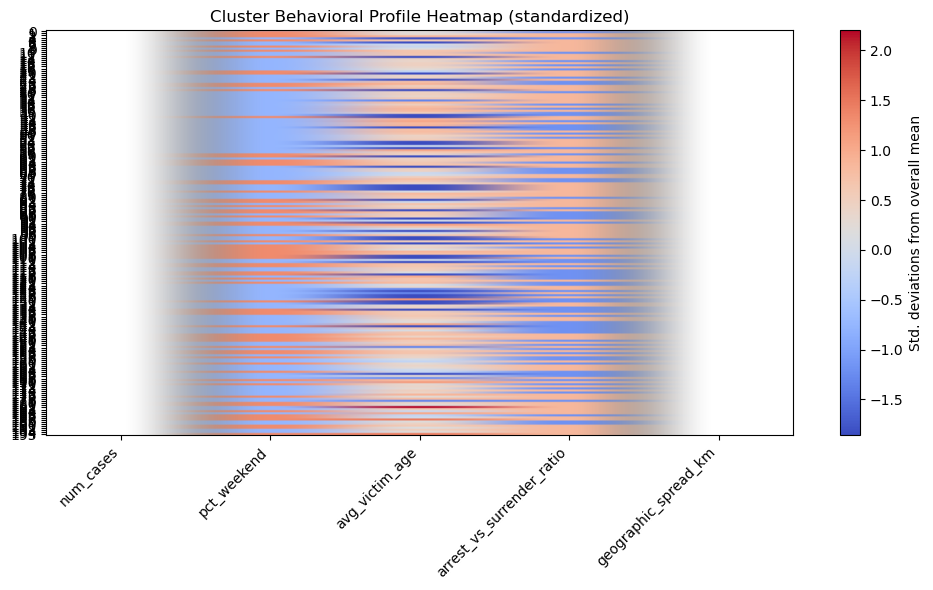

In [13]:
plt.figure(figsize=(10, 6))
plt.imshow(
    (cluster_profile - cluster_profile.mean()) / cluster_profile.std(),
    aspect="auto", cmap="coolwarm"
)
plt.colorbar(label="Std. deviations from overall mean")
plt.yticks(range(len(cluster_profile)), cluster_profile.index)
plt.xticks(range(len(continuous_cols)), continuous_cols, rotation=45, ha="right")
plt.title("Cluster Behavioral Profile Heatmap (standardized)")
plt.tight_layout()
plt.show()


## 10. Save Results

In [14]:
def save_results(uid_series: pd.Series, feats_df: pd.DataFrame, labels: np.ndarray, output_filename: str):
    logger.info("Assembling final output dataframe...")
    results_df = feats_df.copy()
    results_df.insert(0, "person_uid", uid_series.values)
    results_df["mo_cluster_id"] = labels

    output_path = Path(output_filename)
    output_path.parent.mkdir(parents=True, exist_ok=True)
    results_df.to_csv(output_path, index=False)
    logger.info("Results saved to %s (rows: %d)", output_filename, len(results_df))


# Save with the ORIGINAL readable feature values (not the scaled/PCA'd
# training matrix) so the output CSV stays human-interpretable.
save_results(person_uid, df_raw.drop(columns=["person_uid"]), cluster_labels, OUTPUT_FILE)


2026-07-26 09:16:47,249 | INFO     | Assembling final output dataframe...
2026-07-26 09:16:47,697 | INFO     | Results saved to mo_cluster_results.csv (rows: 22909)


---
### Summary of what to look at, in order

1. **`n_clusters` / outlier %** from Section 6 — sanity check the scale
   is reasonable for your data size.
2. **Combined rank table** from Section 4 — confirms `eps`/`min_samples`
   weren't cherry-picked off one metric.
3. **Entropy check in Section 8 — the most important one.** If average
   entropy is low, don't trust the clusters as MO groups yet; go fix
   the categorical encoding or upstream aggregation before trusting
   anything downstream of this notebook.
4. **Heatmap in Section 9** — once entropy looks healthy, this tells
   you *what* actually defines each cluster behaviorally.


In [15]:
import os

# Define the filename variable
OUTPUT_FILE = "mo_cluster_results.csv"

# Check if the file exists
if os.path.exists(OUTPUT_FILE):
    print(f"Success! File found at: {os.path.abspath(OUTPUT_FILE)}")
else:
    print("File not found yet. Make sure you have run the cell that executes the df.to_csv() function.")

Success! File found at: C:\Users\pardh\AI-Driven_Crime_Analytics_And_Visualization\mo_cluster_results.csv
